### DFT as a Matrix

For $N = 2^n$, the DFT matrix has entries:

$$
F_{jk} = \frac{1}{\sqrt{N}} \, \omega^{jk}, \quad \text{where } \omega = e^{-2\pi i / N}
$$

This matrix is **unitary**: $F^\dagger F = I$.


$$
F_N = \frac{1}{\sqrt{N}} \begin{bmatrix}
 1 & 1 & 1 & 1 & \cdots & 1 \\
 1 & \omega & \omega^2 & \omega^3 & \cdots & \omega^{N-1} \\
 1 & \omega^2 & \omega^4 & \omega^6 & \cdots & \omega^{2(N-1)} \\
 1 & \omega^3 & \omega^6 & \omega^9 & \cdots & \omega^{3(N-1)} \\
 \vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
 1 & \omega^{N-1} & \omega^{2(N-1)} & \omega^{3(N-1)} & \cdots & \omega^{(N-1)(N-1)}
\end{bmatrix},
$$

### Example: 2‑point DFT (Hadamard Gate)

For $N=2$, $\omega = -1$:

$$
F_2 = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} = H
$$

The Hadamard gate is the 1‑qubit QFT!

$$
F_4 = \frac{1}{2} \begin{bmatrix}
 1 & 1 & 1 & 1 \\
 1 & i & -1 & -i \\
 1 & -1 & 1 & -1 \\
 1 & -i & -1 & i
\end{bmatrix}
$$

## Part 2: The Quantum Fourier Transform (QFT)

The QFT is the **exact same transformation** as the DFT, but applied to a **quantum state**:

$$
\text{QFT}: \quad |j\rangle \;\longrightarrow\; \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \, j k / N} |k\rangle
$$

*(Note: The sign convention in quantum literature often uses $+$ in the exponent, but this is just a convention – the inverse QFT uses the minus sign.)*

### Product Representation (Key for Circuit)

Let $N = 2^n$. Write $j$ in binary: $j = j_1 j_2 \ldots j_n$ (most significant bit first).  
Then:

$$
\text{QFT}|j\rangle = \frac{1}{\sqrt{2^n}} \bigotimes_{l=1}^n \Big( |0\rangle + e^{2\pi i j / 2^{l}} |1\rangle \Big)
$$

Equivalently:

$$
\text{QFT}|j_1 j_2 \ldots j_n\rangle = \frac{1}{\sqrt{2^n}} \left(|0\rangle + e^{2\pi i 0.j_n}|1\rangle\right) \otimes \left(|0\rangle + e^{2\pi i 0.j_{n-1}j_n}|1\rangle\right) \otimes \cdots \otimes \left(|0\rangle + e^{2\pi i 0.j_1 j_2 \ldots j_n}|1\rangle\right)
$$

where $0.j_l j_{l+1} \ldots j_n$ denotes the binary fraction $j_l/2 + j_{l+1}/4 + \cdots + j_n/2^{n-l+1}$.

![qft circuit](qft.png)

$$
H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \qquad
\text{and} \qquad  
R_k = \begin{pmatrix} 1 & 0 \\ 0 & e^{i2\pi/2^k}  \end{pmatrix}
$$

### Complexity Comparison
- Each qubit gets one Hadamard gate.
- Followed by controlled rotations from less significant qubits.
- Total gate count: $O(n^2)$.
- **Exponential speedup** over classical FFT ($O(n 2^n)$ classical vs $O(n^2)$ quantum gates).

## Periodicity and the DFT

The DFT excels at answering: *What frequencies are present in a signal?*  
Equivalently: *What is the period of a repeating pattern?*

Consider a discrete signal $x_0, x_1, \ldots, x_{N-1}$ that is **exactly periodic** with period $r$, and assume that the signal length $N$ is an integer multiple of $r$. Then for all $j$:

$$
x_{j+r} = x_j .
$$

If we take the DFT of such a signal, the magnitude spectrum will show non‑zero values only at **bin indices** that are integer multiples of $N/r$.  
**Example:** Let $N = 16$ and $r = 4$. We define one period of the signal as the pattern $[1, 0, 0, 0]$, and we shift the starting point by an offset $x_0 = 2$. The resulting 16‑sample signal is:

$$
\begin{aligned}
x &= [\underbrace{0, 0}_{\text{shift}}, \underbrace{1, 0, 0, 0}_{\text{period 1}}, \underbrace{1, 0, 0, 0}_{\text{period 2}}, \underbrace{1, 0, 0, 0}_{\text{period 3}}, \underbrace{1, 0, 0, 0}_{\text{period 4}}] \\
  &= [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0].
\end{aligned}
$$

(Indices: $x_0 = 0$, $x_1 = 0$, $x_2 = 1$, $x_3 = 0$, $x_4 = 0$, $x_5 = 0$, $x_6 = 1$, …, $x_{15} = 0$.)

The DFT of this sequence has non‑zero magnitude **only** at bin indices $k = 0, 4, 8, 12$. The corresponding complex DFT coefficients are:

$$
\begin{aligned}
X_0 &= 4, \\
X_4 &= 1 - i \quad (\text{magnitude } \sqrt{2} \approx 1.414), \\
X_8 &= 0, \\
X_{12} &= 1 + i \quad (\text{magnitude } \sqrt{2} \approx 1.414).
\end{aligned}
$$

(After normalisation by $1/\sqrt{N}$ these would be the quantum amplitudes.)

In terms of **normalized frequency** $f = k/N$ (cycles per sample), the peaks occur at $f = 0,\; 0.25,\; 0.5,\; 0.75$.

The **spacing between consecutive peaks** is:

- **In bin index:** $\Delta k = \dfrac{N}{r} = 4$.
- **In frequency:** $\Delta f = \dfrac{1}{r} = 0.25$.

Thus, by measuring the distance between bright DFT bins, we can directly extract the period $r = \dfrac{N}{\Delta k} = \dfrac{1}{\Delta f} = 4$.

> **Note:** When $r$ does **not** divide $N$, the signal is not perfectly periodic on the analysis window (it is truncated), and the DFT exhibits spectral leakage. The peaks are no longer perfectly isolated, but their spacing still *approximately* equals $N/r$. In the quantum case, however, periodicity is defined modulo $N$ on a cyclic group, which avoids truncation artifacts entirely.

**Classical example:** a sequence of 1s and 0s repeating every 4 samples.

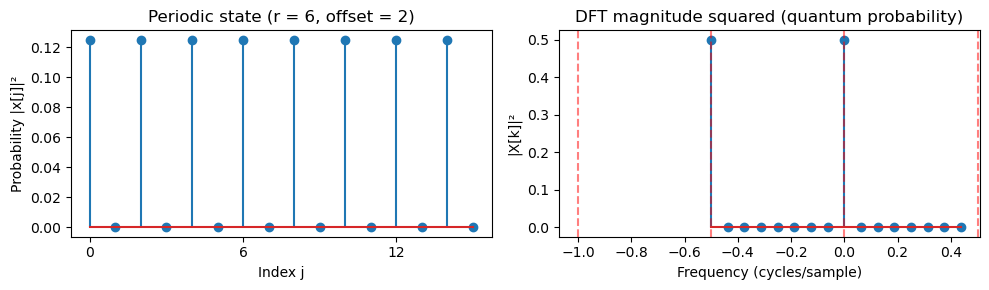

DFT PERIOD FINDING ANALYSIS
N = 16, r = 6, x0 = 2
gcd(N, r) = 2
Number of distinct states M = N / gcd(N,r) = 8
Expected DFT peak bins (multiples of N/g = 8): [0 8]
Expected peak frequencies (cycles/sample): [0.  0.5]
Actual non‑zero bins: [0 8]
Actual non‑zero frequencies: [ 0.  -0.5]
DFT probabilities at those bins: [0.5 0.5]

Bin spacing Δk = N / gcd(N,r) = 8
Frequency spacing Δf = gcd(N,r) / N = 0.125 cycles/sample


In [8]:
# Classical period finding with DFT (corrected)
import numpy as np
import matplotlib.pyplot as plt

N = 16          # signal length
r = 6           # period (does NOT need to divide N)
x0 = 2          # offset

# Build the periodic comb: 1 at indices x0 + m*r (mod N)
x = np.zeros(N)
g = np.gcd(N, r)                # gcd(N, r)
M = N // g                      # number of distinct elements in the subgroup
for m in range(M):
    idx = (x0 + m * r) % N
    x[idx] = 1.0

# Normalize like a quantum state
x = x / np.linalg.norm(x)

# Compute DFT (unitary normalization: divide by sqrt(N) manually)
X = np.fft.fft(x) / np.sqrt(N)   # now matches quantum QFT convention
freq = np.fft.fftfreq(N)         # frequencies in cycles/sample

# Plot
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.stem(range(N), np.abs(x)**2)   # show probabilities
plt.title(f'Periodic state (r = {r}, offset = {x0})')
plt.xlabel('Index j')
plt.ylabel('Probability |x[j]|²')
plt.xticks(range(0, N, r))

plt.subplot(1, 2, 2)
plt.stem(freq, np.abs(X)**2)       # show probabilities after QFT
plt.title('DFT magnitude squared (quantum probability)')
plt.xlabel('Frequency (cycles/sample)')
plt.ylabel('|X[k]|²')

# Draw vertical lines at expected peak frequencies
# Peaks occur at multiples of g/N (both positive and negative)
peak_freqs = np.arange(0, N, N//g) * (1/N)   # in cycles/sample
for f in peak_freqs:
    plt.axvline(f, color='red', linestyle='--', alpha=0.5)
    plt.axvline(f - 1, color='red', linestyle='--', alpha=0.5)  # wrap negative freqs

plt.tight_layout()
plt.show()

# Analysis output
print("=" * 50)
print("DFT PERIOD FINDING ANALYSIS")
print(f"N = {N}, r = {r}, x0 = {x0}")
print(f"gcd(N, r) = {g}")
print(f"Number of distinct states M = N / gcd(N,r) = {M}")
print(f"Expected DFT peak bins (multiples of N/g = {N//g}): {np.arange(0, N, N//g)}")
print(f"Expected peak frequencies (cycles/sample): {np.arange(0, N, N//g) * (1/N)}")
non_zero_bins = np.where(np.abs(X) > 1e-10)[0]
print(f"Actual non‑zero bins: {non_zero_bins}")
print(f"Actual non‑zero frequencies: {freq[non_zero_bins]}")
print(f"DFT probabilities at those bins: {np.abs(X[non_zero_bins])**2}")
print()
print(f"Bin spacing Δk = N / gcd(N,r) = {N//g}")
print(f"Frequency spacing Δf = gcd(N,r) / N = {g/N:.3f} cycles/sample")
print("=" * 50)

### Why This Matters for Quantum Period Finding

The **Quantum Fourier Transform (QFT)** performs exactly the same linear transformation as the DFT, but on a quantum superposition.  

- If we encode a periodic signal into the amplitudes of a quantum state `|ψ⟩ = ∑_j x_j |j⟩`, the QFT maps it to `∑_k X_k |k⟩`.  
- The probability of measuring basis state `|k⟩` is proportional to `|X_k|²`.  
- As in the classical case, the probability mass concentrates on those `|k⟩` whose indices are multiples of `N/r`.

---

Thus, by preparing a periodic quantum state and applying the QFT, we can **measure the period `r`** from the spacing of the bright computational basis states. This is the core principle behind Shor’s factoring algorithm and many other quantum algorithms that rely on period finding.

## Quantum Period Finding – The Heart of Shor’s Algorithm

In quantum period finding we are given a unitary $U$ that implements a periodic function:

$$  
f(x) = f(x + r) \quad\text{with unknown period } r.
$$

---

We prepare the superposition $\frac{1}{\sqrt{N}}\sum_x |x\rangle|f(x)\rangle$, measure the second register, and obtain a state proportional to:

$$  
\sum_{m=0}^{M-1} |x_0 + m r\rangle
$$

where $x_0$ is the measured value and $M \approx N/r$.

Applying the **QFT** to the first register maps this periodic comb to a state whose amplitudes are sharply peaked near multiples of $N/r$. 
- In the general case where $r$ does not divide $N$, the peaks are exactly at multiples of $N/\gcd(N,r)$

## Fourier Analysis of a Periodic Additive State on ℤ_N

We prepare an **n**‑qubit state (Hilbert space dimension `N = 2ⁿ`) that is a uniform superposition over equally spaced basis states modulo `N`:

$$
|\psi\rangle = \frac{1}{\sqrt{M}} \sum_{m=0}^{M-1} |x_0 + m\cdot r \bmod N\rangle
$$

where `r` is the step size and `x₀` is an arbitrary offset.  
Because the sequence repeats after `M` steps, the number of distinct basis states is  

$$
M = \frac{N}{\gcd(N,r)} .
$$

Applying the Quantum Fourier Transform (QFT) to this state yields a new state whose probability distribution is concentrated on basis states `|k⟩` where the phase factor $e^{2\pi i k r / N}$ equals `1`. This condition is

$$
\frac{k r}{N} \in \mathbb{Z} \quad\Longleftrightarrow\quad k \cdot r \equiv 0 \pmod{N}.
$$

Let $g = gcd(N,r)$. Dividing the congruence by $g$ gives  

$$
k \cdot \frac{r}{g} \equiv 0 \pmod{\frac{N}{g}} .
$$

Since $r/g$ and $N/g$ are coprime, we must have  

$$
k \equiv 0 \pmod{\frac{N}{g}} .
$$

Thus the QFT produces **non‑zero amplitudes only at multiples of**  

$$
\Delta = \frac{N}{g} = \frac{N}{\gcd(N,r)} .
$$

The number of such peaks in the interval `[0, N-1]` is exactly $g = gcd(N,r)$.  
(Each peak appears with equal probability when the amplitudes interfere constructively, though the exact distribution of probability among these peaks depends on the offset `x₀`.)

### Important Observations

1. **The spacing is *not* `N/r` in general.**  
   It equals `N/r` **only when** `r` divides `N`. In all other cases the spacing is larger, determined by the greatest common divisor.

2. **Increasing `N` (adding qubits) while keeping `r` fixed increases the spacing `Δ`** because `Δ = N / g` grows with `N`, while the number of peaks `g` stays constant.  
   For example, with `r = 4`:
   - `N = 16` → peaks at 0, 4, 8, 12 (spacing 4).
   - `N = 32` → peaks at 0, 8, 16, 24 (spacing 8).

3. **The QFT reveals the *subgroup structure* of the additive comb.**  
   The peak positions correspond to the quotient group `ℤ_N / ⟨r⟩`, whose size is `gcd(N,r)`.

4. **Relation to Shor’s algorithm:**  
   In Shor’s period‑finding routine, the periodic function is **not** a simple additive step modulo the Hilbert space dimension. Instead, a modular exponentiation function is used, and the QFT is applied to a register of size `Q ≫ r²`. The resulting peak spacing is approximately `Q/r`, and `r` is recovered via continued fractions. The toy model discussed here is an instructive but distinct demonstration of the QFT on a finite cyclic group.



Parameters: r = 6, n_qubits = 4, N = 16, offset x0 = 2 (mod r)
Input state – non‑zero basis states (total 8):
  |0000⟩ (dec   0) : amp = 0.354+0.000j, prob = 0.125
  |0010⟩ (dec   2) : amp = 0.354+0.000j, prob = 0.125
  |0100⟩ (dec   4) : amp = 0.354+0.000j, prob = 0.125
  |0110⟩ (dec   6) : amp = 0.354+0.000j, prob = 0.125
  |1000⟩ (dec   8) : amp = 0.354+0.000j, prob = 0.125
  |1010⟩ (dec  10) : amp = 0.354+0.000j, prob = 0.125
  |1100⟩ (dec  12) : amp = 0.354+0.000j, prob = 0.125
  |1110⟩ (dec  14) : amp = 0.354+0.000j, prob = 0.125


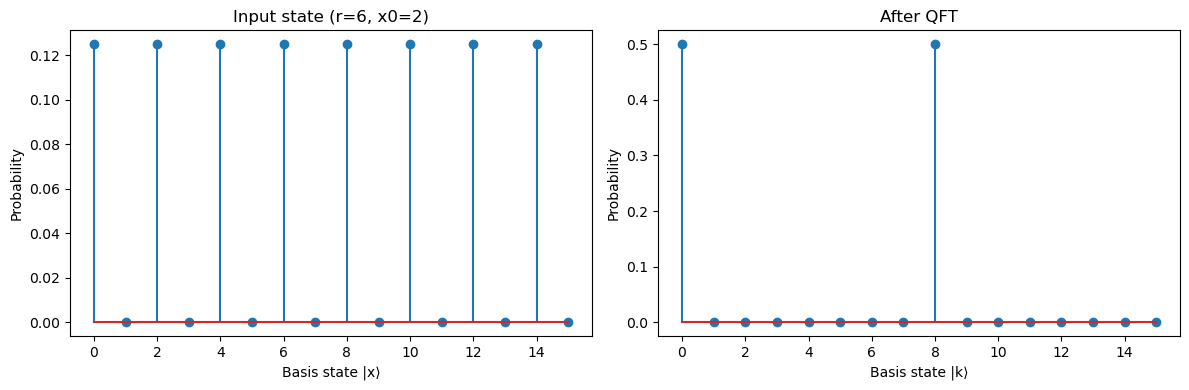


QFT output analysis:
  gcd(N, r) = 2
  Expected peak spacing = N / gcd(N,r) = 8
  Number of peaks = gcd(N,r) = 2
  Top 5 measured |k⟩ (by probability):
    |1000⟩ (dec   8) : prob = 0.5000
    |0000⟩ (dec   0) : prob = 0.5000
    |1101⟩ (dec  13) : prob = 0.0000
    |1111⟩ (dec  15) : prob = 0.0000
    |1100⟩ (dec  12) : prob = 0.0000

  ⚠️  r does not divide N, so the QFT reveals the subgroup spacing (gcd(N,r) peaks).
     This is expected – the Fourier transform shows the subgroup structure.
QFT output state vector – non‑zero basis states (total 2):
  |0000⟩ (dec   0) : amp = 0.707+0.000j, prob = 0.500
  |1000⟩ (dec   8) : amp = 0.707+0.000j, prob = 0.500


In [12]:
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# ---------- Helper for binary formatting ----------
def to_binary_string(value, n_bits):
    """Return binary string of `value` padded to `n_bits`."""
    return format(value, f'0{n_bits}b')

def print_state_binary(state_vector, n_qubits, top_n=10, label="State"):
    """Print the amplitudes and binary representation of non‑zero basis states."""
    N = len(state_vector)
    nonzero = np.abs(state_vector) > 1e-10
    indices = np.where(nonzero)[0]
    print(f"{label} – non‑zero basis states (total {len(indices)}):")
    for i in indices[:top_n]:
        amp = state_vector[i]
        prob = np.abs(amp)**2
        print(f"  |{to_binary_string(i, n_qubits)}⟩ (dec {i:3d}) : amp = {amp.real:.3f}{amp.imag:+.3f}j, prob = {prob:.3f}")
    if len(indices) > top_n:
        print(f"  ... and {len(indices)-top_n} more")

# ---------- Periodic State Preparation ----------
def periodic_state(r, n_qubits, x0=0):
    """
    Create state: uniform superposition of |x0 + m·r mod N⟩ for m = 0..M-1.
    Returns state vector and the offset x0 (reduced modulo r for display).
    """
    N = 2**n_qubits
    x0 = x0 % r   # for display purposes only; actual offset is x0 modulo N
    state = np.zeros(N, dtype=complex)
    m = 0
    while True:
        idx = (x0 + m * r) % N
        if state[idx] != 0:      # we've looped back
            break
        state[idx] = 1.0
        m += 1
    state /= np.linalg.norm(state)
    return state, x0

# ---------- QFT Circuit ----------
def qft_circuit(wires):
    """QFT with big‑endian output (standard binary order)."""
    n = len(wires)
    for i in range(n):
        qml.Hadamard(wires=wires[i])
        for j in range(i + 1, n):
            angle = np.pi / (2 ** (j - i))
            qml.ControlledPhaseShift(angle, wires=[wires[j], wires[i]])
    # Reverse qubit order so output is in usual binary ordering
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - i - 1]])

# ---------- Main Demo ----------
def qft_period_demo(r=3, n_qubits=4, x0=0):
    N = 2**n_qubits
    target_state, x0_used = periodic_state(r, n_qubits, x0)

    print("\n" + "="*60)
    print(f"Parameters: r = {r}, n_qubits = {n_qubits}, N = {N}, offset x0 = {x0_used} (mod r)")
    print_state_binary(target_state, n_qubits, label="Input state")

    dev = qml.device('default.qubit', wires=n_qubits)

    @qml.qnode(dev)
    def apply_qft(state_vec):
        qml.StatePrep(state_vec, wires=range(n_qubits))
        qft_circuit(wires=range(n_qubits))
        return qml.probs(wires=range(n_qubits))

    probs = apply_qft(target_state)

    # To show actual QFT amplitudes (not just probabilities), we run again to get state vector
    @qml.qnode(dev)
    def get_qft_state(state_vec):
        qml.StatePrep(state_vec, wires=range(n_qubits))
        qft_circuit(wires=range(n_qubits))
        return qml.state()

    qft_state = get_qft_state(target_state)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.stem(range(N), np.abs(target_state)**2)
    ax1.set_title(f'Input state (r={r}, x0={x0_used})')
    ax1.set_xlabel('Basis state |x⟩')
    ax1.set_ylabel('Probability')

    ax2.stem(range(N), probs)
    ax2.set_title('After QFT')
    ax2.set_xlabel('Basis state |k⟩')
    ax2.set_ylabel('Probability')
    ax2.set_xticks(range(0, N, max(1, N//8)))
    plt.tight_layout()
    plt.show()

    # Analysis of QFT output
    top_indices = np.argsort(probs)[-5:][::-1]
    top_probs = probs[top_indices]

    g = np.gcd(N, r)
    spacing = N // g
    num_peaks = g

    print("\nQFT output analysis:")
    print(f"  gcd(N, r) = {g}")
    print(f"  Expected peak spacing = N / gcd(N,r) = {spacing}")
    print(f"  Number of peaks = gcd(N,r) = {num_peaks}")
    print(f"  Top 5 measured |k⟩ (by probability):")
    for k, p in zip(top_indices, top_probs):
        print(f"    |{to_binary_string(k, n_qubits)}⟩ (dec {k:3d}) : prob = {p:.4f}")

    if N % r != 0:
        print("\n  ⚠️  r does not divide N, so the QFT reveals the subgroup spacing (gcd(N,r) peaks).")
        print("     This is expected – the Fourier transform shows the subgroup structure.")

    print_state_binary(qft_state, n_qubits, label="QFT output state vector")
qft_period_demo(r=6, n_qubits=4, x0=2)

In [ ]:
# ---------- Interactive Widget ----------
widgets.interact(qft_period_demo,
                 r=widgets.IntSlider(min=2, max=15, step=1, value=3, description='Period r'),
                 n_qubits=widgets.IntSlider(min=3, max=8, step=1, value=4, description='Qubits'),
                 x0=widgets.IntSlider(min=0, max=15, step=1, value=0, description='Offset x0'));